In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Load built-in Iris dataset
iris = load_iris()

# Create DataFrame for easy exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head(5))
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

In [7]:

df["target"] = iris.target
df["species"] = df["target"].map({0: "Setosa", 1: "Versicolor", 2: "Virginica"})

print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df["species"].value_counts())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# Explanation of the DataFrame creation
# ------------------------------------------------------------

# pd.DataFrame(iris.data, columns=iris.feature_names)
# - iris.data contains all the numerical feature values of the Iris dataset.
# - It is a NumPy array with 150 rows (samples) and 4 columns (features).
# - columns=iris.feature_names assigns meaningful names to each column:
#     • sepal length (cm)
#     • sepal width (cm)
#     • petal length (cm)
#     • petal width (cm)
# - The result is a pandas DataFrame, which is easier to view and analyze than a NumPy array.

# df["target"] = iris.target
# - iris.target contains the class label for each flower.
# - The labels are integers:
#       0 = Setosa
#       1 = Versicolor
#       2 = Virginica
# - This statement creates a new column named "target" and stores these numeric labels.

# df["species"] = df["target"].map({0: "Setosa", 1: "Versicolor", 2: "Virginica"})
# - The map() function replaces each numeric target value with its corresponding species name.
# - Mapping performed:
#       0 → "Setosa"
#       1 → "Versicolor"
#       2 → "Virginica"
# - A new column called "species" is created containing readable class names.
# - This makes the dataset much easier for humans to understand and interpret.

Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Class distribution:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866         

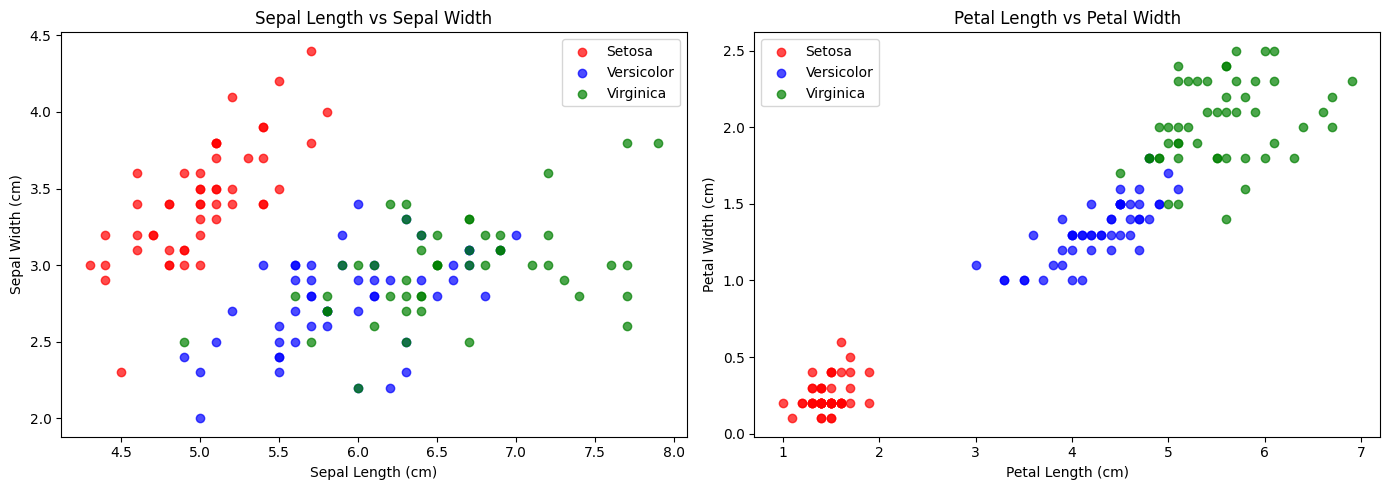

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot-style scatter: Sepal features
for species, color in zip(["Setosa", "Versicolor", "Virginica"], ["red", "blue", "green"]):
    subset = df[df["species"] == species]
    axes[0].scatter(subset["sepal length (cm)"], subset["sepal width (cm)"],
                    label=species, color=color, alpha=0.7)
axes[0].set_title("Sepal Length vs Sepal Width")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].legend()

# Petal features
for species, color in zip(["Setosa", "Versicolor", "Virginica"], ["red", "blue", "green"]):
    subset = df[df["species"] == species]
    axes[1].scatter(subset["petal length (cm)"], subset["petal width (cm)"],
                    label=species, color=color, alpha=0.7)
axes[1].set_title("Petal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Explanation of the for loops
# ------------------------------------------------------------

# zip(["Setosa", "Versicolor", "Virginica"], ["red", "blue", "green"])
# - zip() combines two lists element by element.
# - On each iteration, it returns one species and its corresponding color:
#       ("Setosa", "red")
#       ("Versicolor", "blue")
#       ("Virginica", "green")

# for species, color in zip(...):
# - The loop runs three times (once for each flower species).
# - During each iteration:
#       species stores the current flower name.
#       color stores the color that will represent that species on the graph.

# subset = df[df["species"] == species]
# - Filters the DataFrame to include only rows belonging to the current species.
# - Example:
#       If species = "Setosa", only Setosa flowers are selected.
# - This filtered DataFrame is stored in the variable 'subset'.

# axes[0].scatter(...)
# - Plots the selected subset on the first scatter plot.
# - X-axis: Sepal Length
# - Y-axis: Sepal Width
# - label=species assigns the legend name.
# - color=color gives each species a unique color.
# - alpha=0.7 makes the points slightly transparent so overlapping points are easier to see.

# The second for loop works exactly the same way.
# The only difference is that it plots:
#       X-axis: Petal Length
#       Y-axis: Petal Width
# instead of the sepal measurements.

# Why use a loop?
# - Without a loop, we would have to write separate scatter() statements
#   for Setosa, Versicolor, and Virginica.
# - The loop avoids repeating code and makes the program shorter,
#   cleaner, and easier to maintain.

In [9]:
# Separate features and target
X = iris.data
y = iris.target

# Split data (no scaling needed for Decision Trees —
# they split on thresholds, not distances)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# Train Decision Tree with default settings
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict and evaluate
y_pred = dt.predict(X_test)

print(f"\nAccuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Training samples : 120
Testing  samples : 30

Accuracy : 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



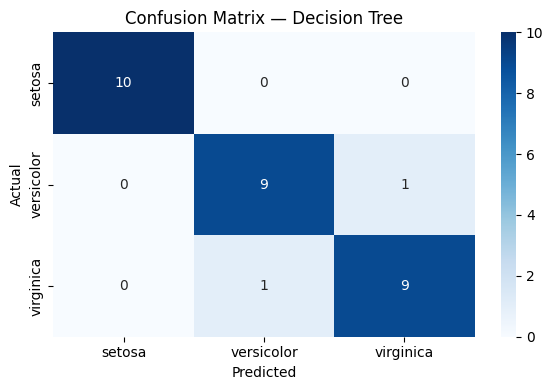

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

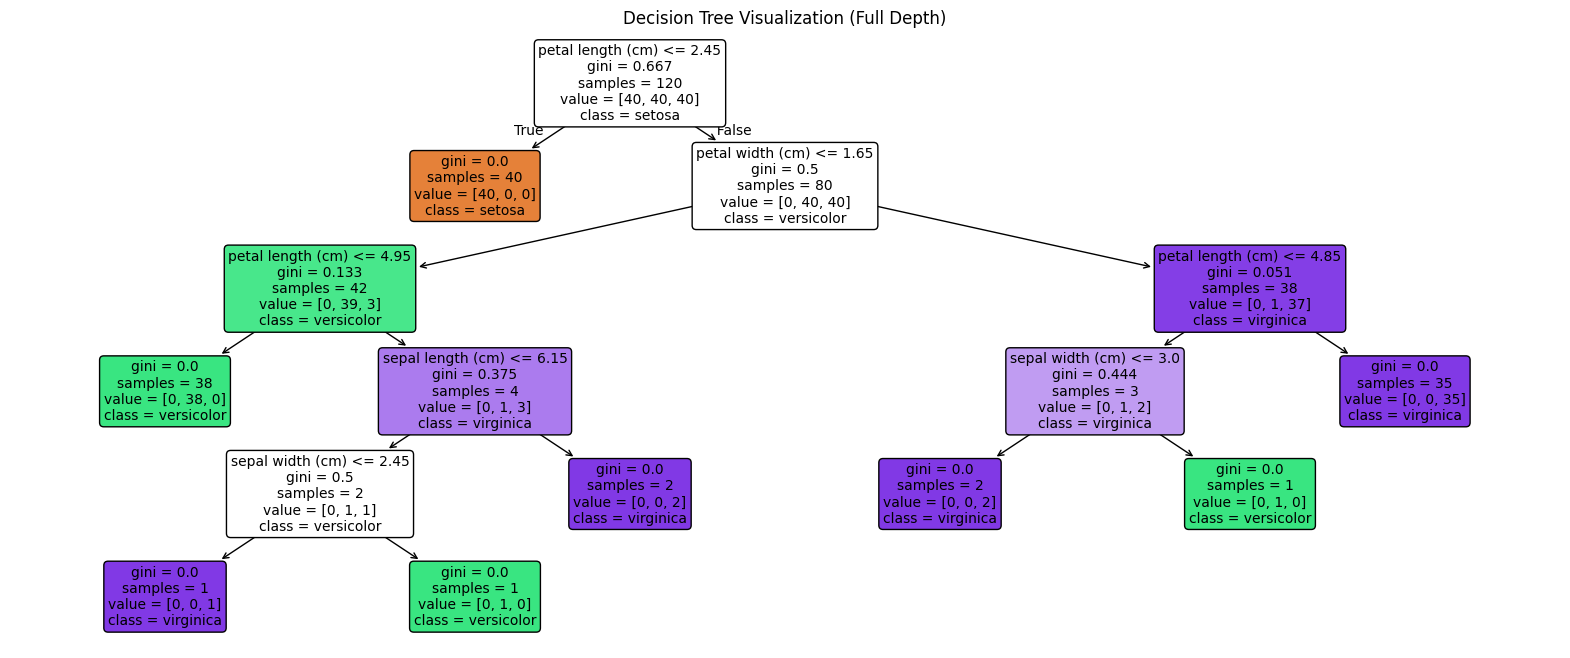

Tree Depth : 5
Total Nodes: 15


In [11]:
plt.figure(figsize=(20, 8))      #dt is the decision tree ( defined in previous cell)
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,        # color nodes by class
    rounded=True,       # rounded node boxes
    fontsize=10
)
plt.title("Decision Tree Visualization (Full Depth)")
plt.show()

print(f"Tree Depth : {dt.get_depth()}")
print(f"Total Nodes: {dt.tree_.node_count}")

Depth 2 → Train: 96.67%  |  Test: 93.33%
Depth 3 → Train: 98.33%  |  Test: 96.67%
Depth 4 → Train: 99.17%  |  Test: 93.33%
Depth 5 → Train: 100.00%  |  Test: 93.33%
Depth 6 → Train: 100.00%  |  Test: 93.33%
Depth 7 → Train: 100.00%  |  Test: 93.33%
Depth 8 → Train: 100.00%  |  Test: 93.33%


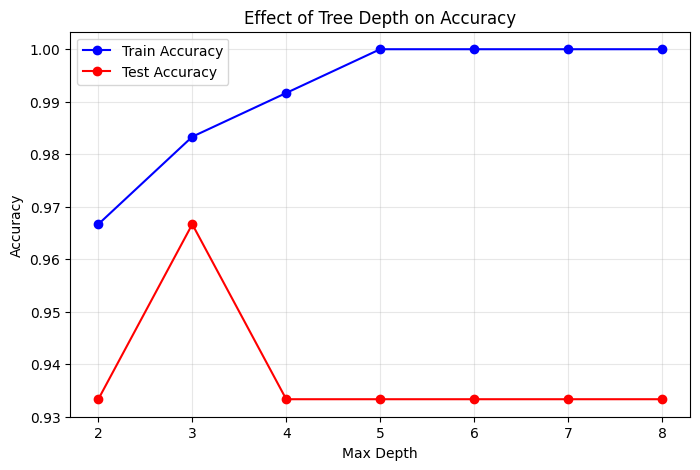

In [12]:
train_accuracies = []
test_accuracies  = []
depths = [2, 3, 4, 5, 6, 7, 8]

for depth in depths:
    dt_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_depth.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dt_depth.predict(X_train))
    test_acc  = accuracy_score(y_test,  dt_depth.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Depth {depth} → Train: {train_acc*100:.2f}%  |  Test: {test_acc*100:.2f}%")

# Plot depth vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(depths, train_accuracies, marker="o", label="Train Accuracy", color="blue")
plt.plot(depths, test_accuracies,  marker="o", label="Test Accuracy",  color="red")
plt.title("Effect of Tree Depth on Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Model: Decision Tree
Accuracy: 93.33%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Model: SVM (RBF)
Accuracy: 96.67%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Model: Logistic Regression
Accuracy: 93.33%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicol

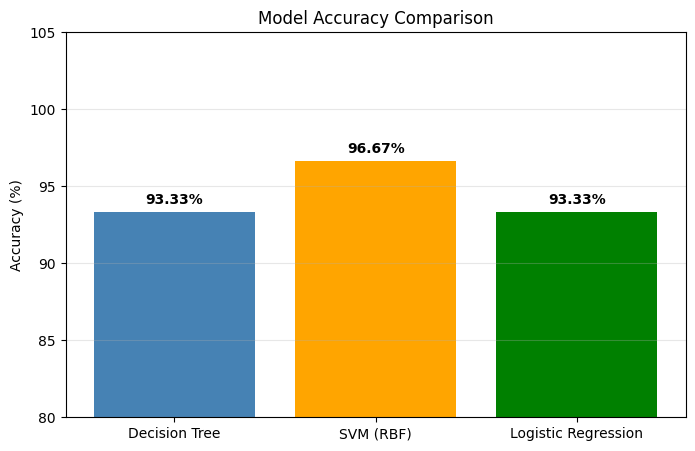

In [13]:
# Scale data for SVM and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Define all three models
models = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "SVM (RBF)"          : SVC(kernel="rbf", random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

results = []

for name, model in models.items():
    # Decision Tree uses unscaled data, others use scaled
    if name == "Decision Tree":
        model.fit(X_train, y_train)
        y_pred_m = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred_m = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_m)
    results.append({"Model": name, "Accuracy": f"{acc*100:.2f}%"})

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred_m, target_names=iris.target_names))

# Summary table
print("\nFinal Comparison:")
print(pd.DataFrame(results).to_string(index=False))

# Bar chart comparison
accs = [float(r["Accuracy"].strip("%")) for r in results]
plt.figure(figsize=(8, 5))
plt.bar(models.keys(), accs, color=["steelblue", "orange", "green"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 105)
plt.grid(True, alpha=0.3, axis="y")
for i, acc in enumerate(accs):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha="center", fontweight="bold")
plt.show()

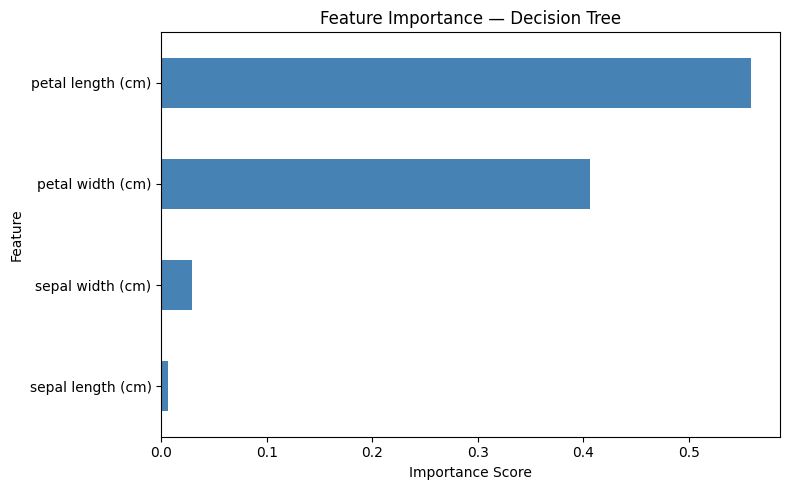

Feature Importance Scores:
petal length (cm)    0.558568
petal width (cm)     0.406015
sepal width (cm)     0.029167
sepal length (cm)    0.006250
dtype: float64


In [14]:
# Decision Trees provide built-in feature importance scores
feature_importance = pd.Series(
    dt.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
print(feature_importance.sort_values(ascending=False))